In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean dataset we saved in Phase 1
df = pd.read_csv("../data/processed/cleaned_retail_sales.csv")

# Make sure Python knows 'Date' is a real calendar date
df['Date'] = pd.to_datetime(df['Date'])

# Show the first 3 rows to confirm everything loaded perfectly
df.head(3)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30


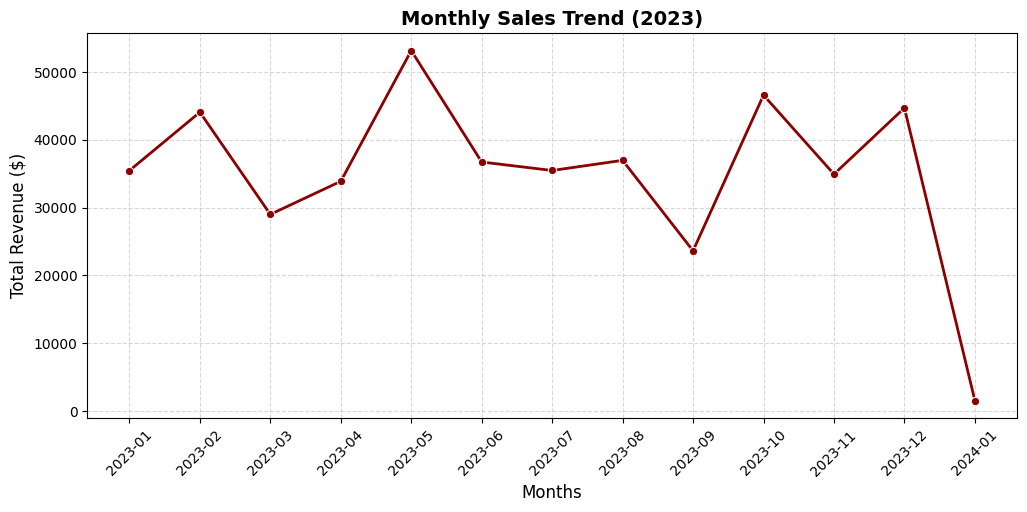

In [2]:
# Create a new temporary column for Year-Month (e.g., '2023-01', '2023-02')
df['Year_Month'] = df['Date'].dt.to_period('M').astype(str)

# Sum up the 'Total Amount' for each unique month
monthly_sales = df.groupby('Year_Month')['Total Amount'].sum().reset_index()

# Set up the plot size
plt.figure(figsize=(12, 5))

# Draw a red line chart with dots on each month
sns.lineplot(data=monthly_sales, x='Year_Month', y='Total Amount', marker='o', color='darkred', linewidth=2)

# Add titles and labels so humans can read it
plt.title('Monthly Sales Trend (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Months', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45) # Tilt the month text so they don't overlap
plt.grid(True, linestyle='--', alpha=0.5) # Add a faint background grid

# Show the final chart on your screen
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_14656\504831062.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_perf, x='Product Category', y='Total Amount', palette='Reds_r')


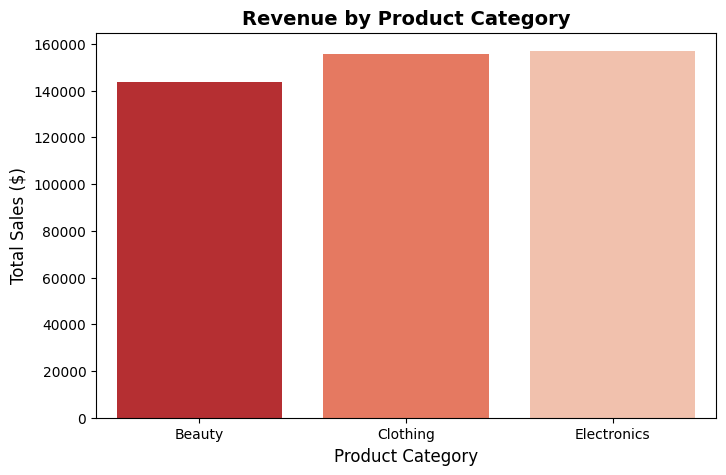

In [3]:
# Calculate total sales for each product category
category_perf = df.groupby('Product Category')['Total Amount'].sum().reset_index()

plt.figure(figsize=(8, 5))

# Draw a bar chart using shades of red
sns.barplot(data=category_perf, x='Product Category', y='Total Amount', palette='Reds_r')

plt.title('Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

plt.show()

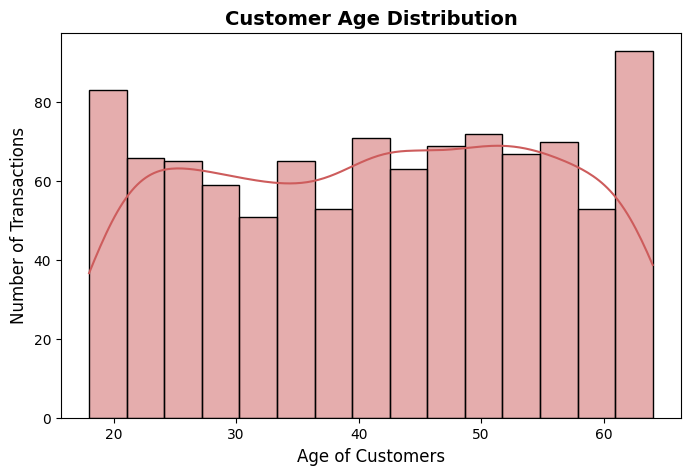

In [4]:
plt.figure(figsize=(8, 5))

# Draw a histogram bar chart showing the age spread
sns.histplot(df['Age'], bins=15, kde=True, color='indianred')

plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age of Customers', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.show()